In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np 

In [2]:
train = pd.read_csv('/kaggle/input/credit-score-classification/train.csv')
test = pd.read_csv('/kaggle/input/credit-score-classification/test.csv')


In [3]:
train.head()

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0x1602,CUS_0xd40,January,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,_,809.98,26.822620,22 Years and 1 Months,No,49.574949,80.41529543900253,High_spent_Small_value_payments,312.49408867943663,Good
1,0x1603,CUS_0xd40,February,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.944960,NaN,No,49.574949,118.28022162236736,Low_spent_Large_value_payments,284.62916249607184,Good
2,0x1604,CUS_0xd40,March,Aaron Maashoh,-500,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,28.609352,22 Years and 3 Months,No,49.574949,81.699521264648,Low_spent_Medium_value_payments,331.2098628537912,Good
3,0x1605,CUS_0xd40,April,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.377862,22 Years and 4 Months,No,49.574949,199.4580743910713,Low_spent_Small_value_payments,223.45130972736786,Good
4,0x1606,CUS_0xd40,May,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,Good,809.98,24.797347,22 Years and 5 Months,No,49.574949,41.420153086217326,High_spent_Medium_value_payments,341.48923103222177,Good


In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  object 
 1   Customer_ID               100000 non-null  object 
 2   Month                     100000 non-null  object 
 3   Name                      90015 non-null   object 
 4   Age                       100000 non-null  object 
 5   SSN                       100000 non-null  object 
 6   Occupation                100000 non-null  object 
 7   Annual_Income             100000 non-null  object 
 8   Monthly_Inhand_Salary     84998 non-null   float64
 9   Num_Bank_Accounts         100000 non-null  int64  
 10  Num_Credit_Card           100000 non-null  int64  
 11  Interest_Rate             100000 non-null  int64  
 12  Num_of_Loan               100000 non-null  object 
 13  Type_of_Loan              88592 non-null   ob

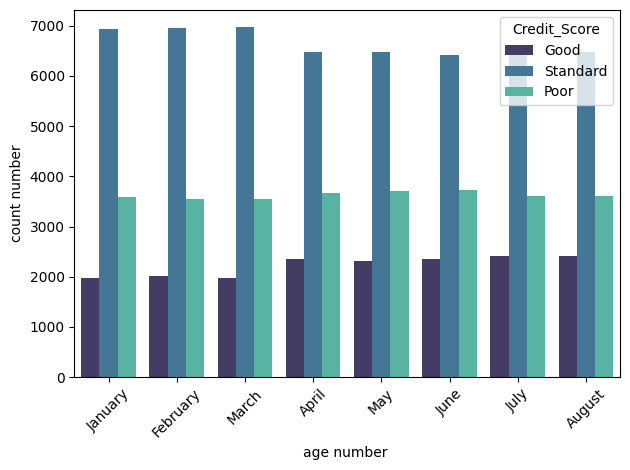

In [6]:
sns.countplot(x = 'Month',data= train,hue = 'Credit_Score',palette = 'mako')
plt.xlabel('age number ')
plt.ylabel('count number')
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

In [7]:
train.columns

Index(['ID', 'Customer_ID', 'Month', 'Name', 'Age', 'SSN', 'Occupation',
       'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts',
       'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Type_of_Loan',
       'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
       'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt',
       'Credit_Utilization_Ratio', 'Credit_History_Age',
       'Payment_of_Min_Amount', 'Total_EMI_per_month',
       'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance',
       'Credit_Score'],
      dtype='object')

In [8]:
mis_col = ['Monthly_Inhand_Salary','Type_of_Loan','Num_of_Delayed_Payment','Num_Credit_Inquiries','Credit_History_Age','Amount_invested_monthly','Monthly_Balance']

In [9]:
midien = train['Num_Credit_Inquiries'].median()

In [10]:
train['Num_Credit_Inquiries'].fillna(midien)

0        4.0
1        4.0
2        4.0
3        4.0
4        4.0
        ... 
99995    3.0
99996    3.0
99997    3.0
99998    3.0
99999    3.0
Name: Num_Credit_Inquiries, Length: 100000, dtype: float64

In [11]:
(train[mis_col].isnull().sum()/len(train))*100

Monthly_Inhand_Salary      15.002
Type_of_Loan               11.408
Num_of_Delayed_Payment      7.002
Num_Credit_Inquiries        1.965
Credit_History_Age          9.030
Amount_invested_monthly     4.479
Monthly_Balance             1.200
dtype: float64

In [12]:
object_col = train.select_dtypes(include = ['object']).columns

In [13]:
for i in object_col:
    print(train[i].value_counts())
    print('+++++++++++++++++++++++++++++++')
    

ID
0x1602     1
0x19c88    1
0x19caa    1
0x19ca5    1
0x19ca4    1
          ..
0xd94d     1
0xd94c     1
0xd94b     1
0xd94a     1
0x25fed    1
Name: count, Length: 100000, dtype: int64
+++++++++++++++++++++++++++++++
Customer_ID
CUS_0xd40     8
CUS_0x9bf4    8
CUS_0x5ae3    8
CUS_0xbe9a    8
CUS_0x4874    8
             ..
CUS_0x2eb4    8
CUS_0x7863    8
CUS_0x9d89    8
CUS_0xc045    8
CUS_0x942c    8
Name: count, Length: 12500, dtype: int64
+++++++++++++++++++++++++++++++
Month
January     12500
February    12500
March       12500
April       12500
May         12500
June        12500
July        12500
August      12500
Name: count, dtype: int64
+++++++++++++++++++++++++++++++
Name
Langep            44
Stevex            44
Vaughanl          39
Jessicad          39
Raymondr          38
                  ..
Alina Selyukhg     4
Habboushg          4
Mortimerq          4
Ronaldf            4
Timothyl           3
Name: count, Length: 10139, dtype: int64
+++++++++++++++++++++++++++++++
Ag

> **Identify issue:**

1.missing value 
['Monthly_Inhand_Salary','Type_of_Loan','Num_of_Delayed_Payment','Num_Credit_Inquiries','Credit_History_Age','Amount_invested_monthly','Monthly_Balance']

2.not usefull columns 

['ID', 'Customer_ID', 'Name','SSN']
3.categorical columns
['Month',Occupation,Payment_of_Min_Amount,Credit_Score

4.numerical col
[Age,

5.unexpected value
[Occupation
_______          7062
Annual_Income
Num_of_Loan
Type of loan
Num_of_Delayed_Payment
Changed_Credit_Limit
Credit_Mix
Outstanding_Debt
Credit_History_Age
Amount_invested_monthly
Payment_Behaviour
Monthly_Balance

> That "_______" is clearly an unexpected or invalid placeholder, not a real occupation. Let’s fix it systematically.

In [14]:
train['Occupation'] = train['Occupation'].replace('_______',np.nan)
train['Occupation'] = train['Occupation'].fillna('Unknown')

> These should be numbers, but because of that ( _ ) they are treated as strings (object type).

In [15]:
train['Annual_Income'] = train['Annual_Income'].astype(str).str.replace(r'[^0-9./-]','',regex = True)
train['Annual_Income'] = pd.to_numeric(train['Annual_Income'],errors = 'coerce')

In [16]:
train['Num_of_Loan'] = train['Num_of_Loan'].astype(str).str.replace(r'[^0-9./-]','',regex = True)
train['Num_of_Loan'] = pd.to_numeric(train['Num_of_Loan'],errors = 'coerce')

In [17]:
train['Type_of_Loan']  = train['Type_of_Loan'].replace(['Not Specified',''],np.nan)

In [18]:
train['Type_of_Loan'].astype(str).apply(lambda x: [i.strip() for i in x.split(',')])


0        [Auto Loan, Credit-Builder Loan, Personal Loan...
1        [Auto Loan, Credit-Builder Loan, Personal Loan...
2        [Auto Loan, Credit-Builder Loan, Personal Loan...
3        [Auto Loan, Credit-Builder Loan, Personal Loan...
4        [Auto Loan, Credit-Builder Loan, Personal Loan...
                               ...                        
99995                        [Auto Loan, and Student Loan]
99996                        [Auto Loan, and Student Loan]
99997                        [Auto Loan, and Student Loan]
99998                        [Auto Loan, and Student Loan]
99999                        [Auto Loan, and Student Loan]
Name: Type_of_Loan, Length: 100000, dtype: object

In [19]:
train['Type_of_Loan'].value_counts()

Type_of_Loan
Credit-Builder Loan                                                                                                                   1280
Personal Loan                                                                                                                         1272
Debt Consolidation Loan                                                                                                               1264
Student Loan                                                                                                                          1240
Payday Loan                                                                                                                           1200
                                                                                                                                      ... 
Not Specified, Mortgage Loan, Auto Loan, and Payday Loan                                                                                 8
Payday Loan, M

In [20]:
train.columns

Index(['ID', 'Customer_ID', 'Month', 'Name', 'Age', 'SSN', 'Occupation',
       'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts',
       'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Type_of_Loan',
       'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
       'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt',
       'Credit_Utilization_Ratio', 'Credit_History_Age',
       'Payment_of_Min_Amount', 'Total_EMI_per_month',
       'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance',
       'Credit_Score'],
      dtype='object')